# Setting

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# # !pip install -q duckdb duckdb-engine ipython-sql

# import duckdb

# %reload_ext sql

# %sql duckdb:///duckdb.db

# %config SqlMagic.autopandas = True
# %config SqlMagic.feedback = False
# %config SqlMagic.displaycon = False

In [ ]:
import pandas as pd
import numpy as np

# Analysis Dataset Creation

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_excel('data.xls')
#data.columns.tolist()
data

,Part Number,D일06~08(08)H 투입계획(발주) 수량,D일08~10(10)H 투입계획(발주) 수량,D일10~12(13)H 투입계획(발주) 수량,D일13~15(15)H 투입계획(발주) 수량,D일15~17(18)H 투입계획(발주) 수량,D일18~20(21)H 투입계획(발주) 수량,D일21~23(23)H 투입계획(발주) 수량,D일23~01(02)H 투입계획(발주) 수량,D일 02~04H 투입계획 수량,...,D+23일 투입예정 수량,D+24일 투입예정 수량,D+25일 투입예정 수량,D+26일 투입예정 수량,D+27일 투입예정 수량,D+28일 투입예정 수량,D+29일 투입예정 수량,D+30일 투입예정 수량,D+31~D+45일 투입예정 수량,CRET_TIME
0,Part 0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,202109131830
1,Part 1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,202109131830
2,Part 2,139,60,80,76,68,81,68,44,0,...,0,0,0,0,0,0,0,0,0,202109131830
3,Part 3,15,11,17,13,12,16,12,8,0,...,0,0,0,0,0,0,0,0,0,202109131830
4,Part 4,40,27,29,17,18,29,18,9,0,...,0,0,0,0,0,0,0,0,0,202109131830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17359,Part 105,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,202111010703
17360,Part 112,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,202111010703
17361,Part 106,141,51,69,55,48,0,0,0,0,...,0,0,0,0,0,0,0,0,0,202111010703
17362,Part 107,104,33,46,46,40,0,0,0,0,...,0,0,0,0,0,0,0,0,0,202111010703


In [ ]:
# Part94인 데이터만 추출일단
data_94 = data[(data["Part Number"]=='Part 94')]
data_94.reset_index(drop=True, inplace=True)
data_94['CRET_TIME']=pd.to_datetime(data_94['CRET_TIME'], format="%Y%m%d%H%M")

/tmp/ipykernel_1863/3113768231.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_94['CRET_TIME']=pd.to_datetime(data_94['CRET_TIME'], format="%Y%m%d%H%M")


In [ ]:
# +12일까지 Partnumber 94의 수량을 예측한 가장 마지막 업데이트만 모은 데이터셋
data_94 = data_94.sort_values('CRET_TIME')

data_94 = (
    data_94
    .groupby([
        data_94['CRET_TIME'].dt.year,
        data_94['CRET_TIME'].dt.month,
        data_94['CRET_TIME'].dt.day
    ])
    .last()
    .reset_index(drop=True)
)

data_94.head()

,Part Number,D일06~08(08)H 투입계획(발주) 수량,D일08~10(10)H 투입계획(발주) 수량,D일10~12(13)H 투입계획(발주) 수량,D일13~15(15)H 투입계획(발주) 수량,D일15~17(18)H 투입계획(발주) 수량,D일18~20(21)H 투입계획(발주) 수량,D일21~23(23)H 투입계획(발주) 수량,D일23~01(02)H 투입계획(발주) 수량,D일 02~04H 투입계획 수량,...,D+23일 투입예정 수량,D+24일 투입예정 수량,D+25일 투입예정 수량,D+26일 투입예정 수량,D+27일 투입예정 수량,D+28일 투입예정 수량,D+29일 투입예정 수량,D+30일 투입예정 수량,D+31~D+45일 투입예정 수량,CRET_TIME
0,Part 94,14,8,4,0,0,0,8,8,0,...,0,0,0,0,0,0,0,0,0,2021-09-13 18:30:00
1,Part 94,13,7,4,0,0,0,9,7,0,...,0,0,0,0,0,0,0,0,0,2021-09-14 17:30:00
2,Part 94,14,4,4,4,4,4,4,2,0,...,0,0,0,0,0,0,0,0,0,2021-09-15 16:33:00
3,Part 94,21,4,4,4,4,4,4,2,0,...,0,0,0,0,0,0,0,0,0,2021-09-16 17:06:00
4,Part 94,20,4,4,4,4,4,4,2,0,...,0,0,0,0,0,0,0,0,0,2021-09-17 06:32:00


In [ ]:
# 시간별 업데이트 된 발주량의 총합이 당일 발주량과 동일한지 확인
(data_94.iloc[:, 1:11].sum(axis=1) == data_94["D일 투입예정 수량(D일계획)"]).all()

np.False_

In [ ]:
# 총합이 일치하지 않음을 확인후 추가 검증
mask = data_94.iloc[:, 1:11].sum(axis=1) != data_94["D일 투입예정 수량(D일계획)"]

data_94.loc[mask].iloc[:, [-1] + list(range(1, 12))]


,CRET_TIME,D일06~08(08)H 투입계획(발주) 수량,D일08~10(10)H 투입계획(발주) 수량,D일10~12(13)H 투입계획(발주) 수량,D일13~15(15)H 투입계획(발주) 수량,D일15~17(18)H 투입계획(발주) 수량,D일18~20(21)H 투입계획(발주) 수량,D일21~23(23)H 투입계획(발주) 수량,D일23~01(02)H 투입계획(발주) 수량,D일 02~04H 투입계획 수량,D일 04~06H 투입계획 수량,D일 투입예정 수량(D일계획)
19,2021-10-02 08:35:00,0,0,0,0,0,0,0,0,0,0,41
20,2021-10-03 07:03:00,0,0,0,0,0,0,0,0,0,0,41
31,2021-10-14 16:30:00,0,0,0,0,0,0,0,0,0,0,35
32,2021-10-15 15:34:00,0,0,0,0,0,0,0,0,0,0,35
33,2021-10-16 07:42:00,0,0,0,0,0,0,0,0,0,0,35
34,2021-10-17 06:36:00,0,0,0,0,0,0,0,0,0,0,35
39,2021-10-22 16:03:00,0,0,0,0,0,0,0,0,0,0,35
40,2021-10-23 07:08:00,0,0,0,0,0,0,0,0,0,0,35
41,2021-10-24 06:33:00,0,0,0,0,0,0,0,0,0,0,35


* 총 9개 기록에서 시간대별 발주량 없이 통합 투입예정수량에 직접 반영된 사례를 확인하고, 발생 시점 추적 및 데이터 수집·입력 로직 점검 필요성 제안

* 모델링에는 최종 계획 발주량을 대표하는 D일 투입예정 수량(D일계획) 컬럼만 유지해 일별 발주량 시계열 구성

In [ ]:
data_94= data_94.loc[:, ['Part Number', 'D일 투입예정 수량(D일계획)', 'D+1일 투입예정 수량(Total)', 'D+2일 투입예정 수량(Total)', 'D+3일 투입예정 수량(Total)', 'D+4일 투입예정 수량(Total)', 'D+5일 투입예정 수량', 'D+6일 투입예정 수량', 'D+7일 투입예정 수량', 'D+8일 투입예정 수량', 'D+9일 투입예정 수량', 'D+10일 투입예정 수량', 'D+11일 투입예정 수량', 'D+12일 투입예정 수량','CRET_TIME']]
data_94.columns

Index(['Part Number', 'D일 투입예정 수량(D일계획)', 'D+1일 투입예정 수량(Total)',
       'D+2일 투입예정 수량(Total)', 'D+3일 투입예정 수량(Total)', 'D+4일 투입예정 수량(Total)',
       'D+5일 투입예정 수량', 'D+6일 투입예정 수량', 'D+7일 투입예정 수량', 'D+8일 투입예정 수량',
       'D+9일 투입예정 수량', 'D+10일 투입예정 수량', 'D+11일 투입예정 수량', 'D+12일 투입예정 수량',
       'CRET_TIME'],
      dtype='object')

In [ ]:
# +12일까지 Partnumber 94의 수량을 예측한 가장 마지막 업데이트만 모은 데이터셋
data_94 = data_94.sort_values('CRET_TIME')

data_94 = (
    data_94
    .groupby([
        data_94['CRET_TIME'].dt.year,
        data_94['CRET_TIME'].dt.month,
        data_94['CRET_TIME'].dt.day
    ])
    .last()
    .reset_index(drop=True)
)

data_94.head()

,Part Number,D일 투입예정 수량(D일계획),D+1일 투입예정 수량(Total),D+2일 투입예정 수량(Total),D+3일 투입예정 수량(Total),D+4일 투입예정 수량(Total),D+5일 투입예정 수량,D+6일 투입예정 수량,D+7일 투입예정 수량,D+8일 투입예정 수량,D+9일 투입예정 수량,D+10일 투입예정 수량,D+11일 투입예정 수량,D+12일 투입예정 수량,CRET_TIME
0,Part 94,42,32,30,30,30,38,0,30,30,30,30,30,0,2021-09-13 18:30:00
1,Part 94,40,30,30,30,50,45,30,30,30,30,30,0,0,2021-09-14 17:30:00
2,Part 94,40,30,30,47,43,51,0,0,0,30,30,0,30,2021-09-15 16:33:00
3,Part 94,47,30,0,53,42,39,0,0,30,30,0,30,30,2021-09-16 17:06:00
4,Part 94,46,30,30,44,37,51,0,30,30,0,30,30,30,2021-09-17 06:32:00


# EDA

In [ ]:
def check_structure(df):
      print("\n[Shape]")
      print(df.shape)

      # print("\n[Columns]")
      # print(df.columns)

      # print("\n[Data Types]")
      # print(df.dtypes)

      print("\n[Info]")
      df.info()

      print("\n[Describe]")
      display(df.describe())

      #print("\n[Head]")
      #display(df.head())

def check_null(df):
    null_count = df.isnull().sum()
    null_cols = null_count[null_count > 0]

    if len(null_cols) == 0:
        print("\n결측치가 없습니다.")
    else:
        display(null_cols)

def check_duplicate(df):
    duplicate_count = df.duplicated().sum()

    if duplicate_count == 0:
        print("중복 행이 없습니다.")
    else:
        print(f"중복 행 {duplicate_count}개")

In [ ]:
check_structure(data_94)
check_null(data_94)
check_duplicate(data_94)


[Shape]
(49, 15)

[Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Part Number          49 non-null     object        
 1   D일 투입예정 수량(D일계획)     49 non-null     int64         
 2   D+1일 투입예정 수량(Total)  49 non-null     int64         
 3   D+2일 투입예정 수량(Total)  49 non-null     int64         
 4   D+3일 투입예정 수량(Total)  49 non-null     int64         
 5   D+4일 투입예정 수량(Total)  49 non-null     int64         
 6   D+5일 투입예정 수량         49 non-null     int64         
 7   D+6일 투입예정 수량         49 non-null     int64         
 8   D+7일 투입예정 수량         49 non-null     int64         
 9   D+8일 투입예정 수량         49 non-null     int64         
 10  D+9일 투입예정 수량         49 non-null     int64         
 11  D+10일 투입예정 수량        49 non-null     int64         
 12  D+11일 투입예정 수량        49 non-null     int64         
 13  D+12일 투입예정 

,D일 투입예정 수량(D일계획),D+1일 투입예정 수량(Total),D+2일 투입예정 수량(Total),D+3일 투입예정 수량(Total),D+4일 투입예정 수량(Total),D+5일 투입예정 수량,D+6일 투입예정 수량,D+7일 투입예정 수량,D+8일 투입예정 수량,D+9일 투입예정 수량,D+10일 투입예정 수량,D+11일 투입예정 수량,D+12일 투입예정 수량,CRET_TIME
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.00000,49.000000,49.000000,49.000000,49.000000,49.000000,49
mean,41.081633,21.551020,19.877551,34.142857,34.448980,34.530612,18.448980,27.55102,21.265306,13.714286,24.693878,23.551020,24.489796,2021-10-07 12:03:35.510204416
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,2021-09-13 18:30:00
25%,38.000000,0.000000,0.000000,33.000000,34.000000,34.000000,0.000000,30.00000,0.000000,0.000000,28.000000,0.000000,30.000000,2021-09-25 15:38:00
50%,42.000000,30.000000,30.000000,34.000000,34.000000,34.000000,32.000000,32.00000,30.000000,0.000000,30.000000,30.000000,32.000000,2021-10-07 17:32:00
75%,45.000000,34.000000,34.000000,40.000000,39.000000,39.000000,34.000000,34.00000,34.000000,34.000000,34.000000,34.000000,34.000000,2021-10-19 15:57:00
max,47.000000,34.000000,40.000000,53.000000,52.000000,51.000000,34.000000,34.00000,34.000000,34.000000,34.000000,34.000000,34.000000,2021-11-01 07:03:00
std,4.808139,15.243935,16.147281,12.257651,10.216533,10.905087,16.848666,11.67808,15.175056,16.176114,13.690331,14.533096,14.180565,NaN



결측치가 없습니다.
중복 행이 없습니다.


Text(0, 0.5, 'amount')

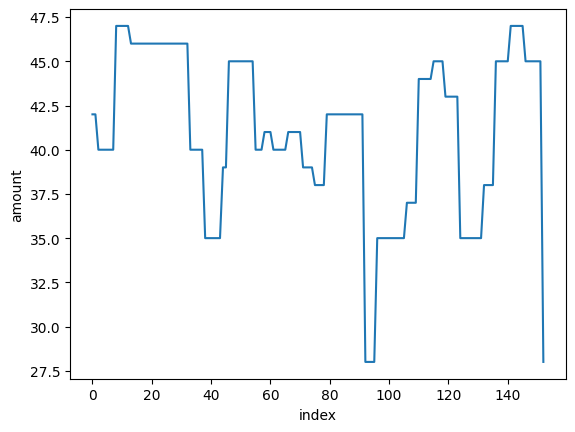

In [ ]:
import matplotlib.pyplot as plt
plt.plot(data_94[['D일 투입예정 수량(D일계획)']])
plt.xlabel('index')
plt.ylabel('amount')

# Feature Engineering

#### **문제**: D일 투입 예정 수량(target)과 관련 있는 feature 찾기 → Correlation

In [ ]:
# 같은 목표 날짜 기준으로 D, D+1, ..., D+12 컬럼을 정렬하기 위해
# D+n 컬럼은 n일 전 row에서 가져오고, 길이를 맞추기 위해 뒤쪽 n개 row를 제외한다.

corr_data_94 = pd.concat([
    data_94.iloc[12:]['D일 투입예정 수량(D일계획)'].reset_index(drop=True),
    data_94.iloc[11:-1]['D+1일 투입예정 수량(Total)'].reset_index(drop=True),
    data_94.iloc[10:-2]['D+2일 투입예정 수량(Total)'].reset_index(drop=True),
    data_94.iloc[9:-3]['D+3일 투입예정 수량(Total)'].reset_index(drop=True),
    data_94.iloc[8:-4]['D+4일 투입예정 수량(Total)'].reset_index(drop=True),
    data_94.iloc[7:-5]['D+5일 투입예정 수량'].reset_index(drop=True),
    data_94.iloc[6:-6]['D+6일 투입예정 수량'].reset_index(drop=True),
    data_94.iloc[5:-7]['D+7일 투입예정 수량'].reset_index(drop=True),
    data_94.iloc[4:-8]['D+8일 투입예정 수량'].reset_index(drop=True),
    data_94.iloc[3:-9]['D+9일 투입예정 수량'].reset_index(drop=True),
    data_94.iloc[2:-10]['D+10일 투입예정 수량'].reset_index(drop=True),
    data_94.iloc[1:-11]['D+11일 투입예정 수량'].reset_index(drop=True),
    data_94.iloc[:-12]['D+12일 투입예정 수량'].reset_index(drop=True)
], axis=1)

corr_data_94.head()

,D일 투입예정 수량(D일계획),D+1일 투입예정 수량(Total),D+2일 투입예정 수량(Total),D+3일 투입예정 수량(Total),D+4일 투입예정 수량(Total),D+5일 투입예정 수량,D+6일 투입예정 수량,D+7일 투입예정 수량,D+8일 투입예정 수량,D+9일 투입예정 수량,D+10일 투입예정 수량,D+11일 투입예정 수량,D+12일 투입예정 수량
0,46,30,30,53,51,45,0,30,30,30,30,0,0
1,46,30,30,33,35,37,0,30,30,0,0,0,0
2,40,30,30,38,42,35,0,30,30,0,30,30,30
3,35,30,30,40,36,25,0,30,30,0,30,30,30
4,39,30,30,38,33,33,0,30,30,0,30,30,30


In [ ]:
corr_data_94.corr().head(1)

,D일 투입예정 수량(D일계획),D+1일 투입예정 수량(Total),D+2일 투입예정 수량(Total),D+3일 투입예정 수량(Total),D+4일 투입예정 수량(Total),D+5일 투입예정 수량,D+6일 투입예정 수량,D+7일 투입예정 수량,D+8일 투입예정 수량,D+9일 투입예정 수량,D+10일 투입예정 수량,D+11일 투입예정 수량,D+12일 투입예정 수량
D일 투입예정 수량(D일계획),1.0,0.651721,0.408578,0.393761,0.136667,0.388251,0.018768,0.127412,0.246102,0.024242,0.215673,0.103277,0.081598


#### **결과 해석**
목표: 3일 전 발주량 예측
        
* D+1, D+2는 사용 대상에서 제외

* D+3 이후의 correlation 확인
      
* 목표일과 가장 가까운 연속 구간 D+3~D+5를 우선 선택

* D+6부터는 상관관계가 전반적으로 약해짐

####  **문제**: 선택한 feature들끼리 중복된 정보를 포함하고 있는가? → VIF(D+3, D+4, D+5)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = corr_data_94[[
    'D+3일 투입예정 수량(Total)',
    'D+4일 투입예정 수량(Total)',
    'D+5일 투입예정 수량'
]]

X = add_constant(X)

vif = pd.DataFrame({
    'feature': X.columns,
    'VIF': [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif

,feature,VIF
0,const,88.469501
1,D+3일 투입예정 수량(Total),1.464299
2,D+4일 투입예정 수량(Total),1.112248
3,D+5일 투입예정 수량,1.553988


#### **결과 해석**

* 다중공산성: 한 입력변수가 나머지 여러 입력변수들로 얼마나 잘 설명되는지를 확인
* D+3~D+5의 VIF가 모두 2 미만으로 나타나, 주요 입력 변수 간 다중공선성이 낮음을 확인
* 결론: D+3, D+4, D+5를 최종 피처로 선정



# Data Preprocessing

In [ ]:
data_94 = data_94.loc[:, [
    'D일 투입예정 수량(D일계획)',
    'D+3일 투입예정 수량(Total)',
    'D+4일 투입예정 수량(Total)',
    'D+5일 투입예정 수량'
]].reset_index(drop=True)

data_94.head()

,D일 투입예정 수량(D일계획),D+3일 투입예정 수량(Total),D+4일 투입예정 수량(Total),D+5일 투입예정 수량
0,42,30,30,38
1,40,30,50,45
2,40,47,43,51
3,47,53,42,39
4,46,44,37,51


In [ ]:
# 사용자 정의 함수 만들기
def to_timeseries_data(data, lookback=3, delay=3):
    # lookback: 입력으로 사용하기 위해 거슬러 올라갈 시간단위의 개수 = 3일
    # delay: target으로 사용할 미래의 시점 = 3일 후

    output_len = len(data) - (lookback + delay) + 1
    n_feature = data.shape[-1]  # feature 수 = 4

    inputs = np.zeros((output_len, lookback, n_feature))  # (N, 3, 4)
    targets = np.zeros((output_len,))                     # (N,)

    for i in range(output_len):
        inputs[i] = data.iloc[i:i + lookback, :]
        targets[i] = data.iloc[i + lookback + delay - 1, 0]

    return inputs, targets


# 사용자 정의 함수 적용
X_94, y_94 = to_timeseries_data(data_94)

print("X의 형태:", X_94.shape)
print("y의 형태:", y_94.shape)

X의 형태: (44, 3, 4)
y의 형태: (44,)


In [ ]:
# train:70, val:10, test:20
from sklearn.model_selection import train_test_split
X_train_94, X_val_94, y_train_94, y_val_94 = train_test_split(X_94, y_94, test_size=0.3, shuffle=False)
X_val_94, X_test_94, y_val_94, y_test_94 = train_test_split(X_val_94,y_val_94, test_size=2/3, shuffle=False)

In [ ]:
print("X 학습: {}, X 검증: {}, X 평가: {}".format(X_train_94.shape,X_val_94.shape,X_test_94.shape))
print("y 학습: {}, y 검증: {}, y 평가: {}".format(y_train_94.shape,y_val_94.shape,y_test_94.shape))

X 학습: (30, 3, 4), X 검증: (4, 3, 4), X 평가: (10, 3, 4)
y 학습: (30,), y 검증: (4,), y 평가: (10,)


In [ ]:
# StandardScaler Input: 2차원 데이터 (행, Feature)
# X_train_94: 30개 샘플, 각 샘플 마다 3일, 각 날짜마다 4개 feature -> [D, D+3, D+4,D+5]
from sklearn.preprocessing import StandardScaler

# X 데이터 표준화
Xscaler_94 = StandardScaler()

X_train_94 = Xscaler_94.fit_transform(X_train_94.reshape(-1, X_train_94.shape[-1])).reshape(X_train_94.shape)

X_val_94 = Xscaler_94.transform(X_val_94.reshape(-1, X_val_94.shape[-1])).reshape(X_val_94.shape)

X_test_94 = Xscaler_94.transform(X_test_94.reshape(-1, X_test_94.shape[-1])).reshape(X_test_94.shape)


# y 데이터 표준화
yscaler_94 = StandardScaler()

y_train_94 = yscaler_94.fit_transform(y_train_94.reshape(-1, 1))

y_val_94 = yscaler_94.transform(y_val_94.reshape(-1, 1))

y_test_94 = yscaler_94.transform(y_test_94.reshape(-1, 1))

# Modeling

## LSTM

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error


# 재현성을 위한 seed
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [ ]:
X_train = torch.tensor(X_train_94, dtype=torch.float32)
y_train = torch.tensor(y_train_94, dtype=torch.float32)

X_val = torch.tensor(X_val_94, dtype=torch.float32)
y_val = torch.tensor(y_val_94, dtype=torch.float32)

X_test = torch.tensor(X_test_94, dtype=torch.float32)
y_test = torch.tensor(y_test_94, dtype=torch.float32)

In [ ]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=8):
        super().__init__()

        # 첫 번째 LSTM
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.dropout1 = nn.Dropout(0.2)

        # 두 번째 LSTM
        self.lstm2 = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.dropout2 = nn.Dropout(0.2)

        # 최종 발주량 1개 출력
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        # (batch, 3, 4)
        x, _ = self.lstm1(x)

        # (batch, 3, 8)
        x = torch.relu(x)
        x = self.dropout1(x)

        x, _ = self.lstm2(x)

        # 마지막 날짜의 hidden state만 사용
        x = x[:, -1, :]

        # (batch, 8)
        x = torch.relu(x)
        x = self.dropout2(x)

        # (batch, 1)
        x = self.fc(x)

        return x

In [ ]:
model = LSTMModel(
    input_size=X_train.shape[-1],  # 4
    hidden_size=8
).to(device)

print(model)

LSTMModel(
  (lstm1): LSTM(4, 8, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(8, 8, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)


In [ ]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters()
)

In [ ]:
epochs = 100
patience = 15

best_val_loss = np.inf
best_model_state = None

wait = 0

train_losses = []
val_losses = []


for epoch in range(1, epochs + 1):

    # -------------------------
    # Train
    # -------------------------
    model.train()

    train_loss_sum = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # 이전 gradient 초기화
        optimizer.zero_grad()

        # 예측
        y_pred = model(X_batch)

        # MAE 계산
        loss = criterion(y_pred, y_batch)

        # 역전파
        loss.backward()

        # 파라미터 업데이트
        optimizer.step()

        train_loss_sum += loss.item() * X_batch.size(0)


    train_loss = train_loss_sum / len(train_loader.dataset)


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss_sum = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)

            loss = criterion(y_pred, y_batch)

            val_loss_sum += loss.item() * X_batch.size(0)


    val_loss = val_loss_sum / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)


    print(
        f"Epoch {epoch:03d} | "
        f"Train MAE: {train_loss:.4f} | "
        f"Val MAE: {val_loss:.4f}"
    )


    # -------------------------
    # Early Stopping
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        wait = 0

    else:
        wait += 1


    if wait >= patience:

        print(f"\nEarly stopping at epoch {epoch}")
        break

Epoch 001 | Train MAE: 0.8076 | Val MAE: 0.7617
Epoch 002 | Train MAE: 0.7966 | Val MAE: 0.7577
Epoch 003 | Train MAE: 0.8051 | Val MAE: 0.7552
Epoch 004 | Train MAE: 0.8011 | Val MAE: 0.7513
Epoch 005 | Train MAE: 0.7976 | Val MAE: 0.7470
Epoch 006 | Train MAE: 0.7979 | Val MAE: 0.7436
Epoch 007 | Train MAE: 0.7905 | Val MAE: 0.7402
Epoch 008 | Train MAE: 0.7877 | Val MAE: 0.7367
Epoch 009 | Train MAE: 0.7888 | Val MAE: 0.7326
Epoch 010 | Train MAE: 0.7887 | Val MAE: 0.7298
Epoch 011 | Train MAE: 0.7907 | Val MAE: 0.7267
Epoch 012 | Train MAE: 0.7842 | Val MAE: 0.7251
Epoch 013 | Train MAE: 0.7880 | Val MAE: 0.7245
Epoch 014 | Train MAE: 0.7839 | Val MAE: 0.7254
Epoch 015 | Train MAE: 0.7886 | Val MAE: 0.7281
Epoch 016 | Train MAE: 0.7868 | Val MAE: 0.7281
Epoch 017 | Train MAE: 0.7879 | Val MAE: 0.7283
Epoch 018 | Train MAE: 0.7765 | Val MAE: 0.7278
Epoch 019 | Train MAE: 0.7862 | Val MAE: 0.7272
Epoch 020 | Train MAE: 0.7812 | Val MAE: 0.7269
Epoch 021 | Train MAE: 0.7845 | Val MAE:

In [ ]:
model.eval()

predictions = []
targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        y_pred = model(X_batch)

        predictions.append(
            y_pred.cpu().numpy()
        )

        targets.append(
            y_batch.numpy()
        )


predictions = np.vstack(predictions)
targets = np.vstack(targets)

scaled_mae = mean_absolute_error(
    targets,
    predictions
)

print("Scaled Test MAE:", scaled_mae)

Scaled Test MAE: 1.2413842678070068


In [ ]:
model.load_state_dict(best_model_state)
model.eval()

LSTMModel(
  (lstm1): LSTM(4, 8, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(8, 8, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)

In [ ]:
# 표준화된 값을 원래 발주량 단위로 복원
y_pred_original = yscaler_94.inverse_transform(predictions)
y_test_original = yscaler_94.inverse_transform(targets)

# 원래 단위에서 MAE 계산
original_mae = mean_absolute_error(
    y_test_original,
    y_pred_original
)

print("Original Scale Test MAE:", original_mae)

Original Scale Test MAE: 5.620454788208008


In [ ]:
result = pd.DataFrame({
    "Actual": y_test_original.flatten(),
    "Predicted": y_pred_original.flatten()
})

result

,Actual,Predicted
0,35.0,40.930843
1,35.0,40.990025
2,35.0,40.992008
3,38.0,40.934330
4,45.0,40.886364
5,45.0,40.880413
6,47.0,40.897823
7,45.0,40.891205
8,45.0,40.996681
9,28.0,40.909828


## XGBoost

In [ ]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error


# ============================================================
# 1. train + validation 결합
#    test 데이터는 최종 평가를 위해 그대로 유지
# ============================================================

X_train_val_xgb = np.concatenate(
    [X_train_xgb, X_val_xgb],
    axis=0
)

y_train_val_xgb = np.concatenate(
    [y_train_xgb, y_val_xgb],
    axis=0
)

print("Train + Val X:", X_train_val_xgb.shape)
print("Train + Val y:", y_train_val_xgb.shape)


# ============================================================
# 2. 기본 XGBoost Regressor
# ============================================================

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    random_state=42
)


# ============================================================
# 3. 탐색할 Hyperparameter 범위
# ============================================================

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


# ============================================================
# 4. Time Series Cross Validation
# ============================================================

tscv = TimeSeriesSplit(n_splits=4)


# ============================================================
# 5. Grid Search
# ============================================================

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,

    # MAE가 작을수록 좋지만 sklearn scoring은 클수록 좋게 설계되어
    # 음수 MAE를 사용
    scoring='neg_mean_absolute_error',

    cv=tscv,
    n_jobs=-1,
    verbose=1
)


# ============================================================
# 6. Hyperparameter 탐색
# ============================================================

grid_search.fit(
    X_train_val_xgb,
    y_train_val_xgb
)


# ============================================================
# 7. Best Parameter 확인
# ============================================================

print("Best Parameters:")
print(grid_search.best_params_)

print(
    "Best CV MAE:",
    -grid_search.best_score_
)


# ============================================================
# 8. 최적 모델
# ============================================================

best_xgb = grid_search.best_estimator_


# ============================================================
# 9. Test 예측
# ============================================================

y_pred_xgb = best_xgb.predict(
    X_test_xgb
).reshape(-1, 1)

y_test_xgb_2d = y_test_xgb.reshape(-1, 1)


# ============================================================
# 10. 표준화 상태 MAE
# ============================================================

scaled_mae = mean_absolute_error(
    y_test_xgb_2d,
    y_pred_xgb
)

print("Scaled Test MAE:", scaled_mae)


# ============================================================
# 11. 원래 발주량 단위로 복원
# ============================================================

y_pred_original = yscaler_94.inverse_transform(
    y_pred_xgb
)

y_test_original = yscaler_94.inverse_transform(
    y_test_xgb_2d
)


# ============================================================
# 12. 최종 MAE
# ============================================================

xgb_tuned_mae = mean_absolute_error(
    y_test_original,
    y_pred_original
)

print(
    "Tuned XGBoost Original Scale MAE:",
    xgb_tuned_mae
)


# ============================================================
# 13. 실제값 vs 예측값
# ============================================================

xgb_tuned_result = pd.DataFrame({
    'Actual': y_test_original.flatten(),
    'Predicted': y_pred_original.flatten()
})

xgb_tuned_result

Train + Val X: (34, 12)
Train + Val y: (34,)
Fitting 4 folds for each of 108 candidates, totalling 432 fits
Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV MAE: 0.6590701586585974
Scaled Test MAE: 1.08110828216065
Tuned XGBoost Original Scale MAE: 4.894793319702148


,Actual,Predicted
0,35.0,43.056770
1,35.0,44.119453
2,35.0,43.381634
3,38.0,37.077801
4,45.0,37.502289
5,45.0,41.432514
6,47.0,42.209816
7,45.0,43.465294
8,45.0,44.548908
9,28.0,32.626698
